In [ ]:
# Task 1: Exploratory Data Analysis (EDA) — Retail Transactions & Business Intelligence

## Core Analytical Questions
##1. Which product categories yield the highest aggregate revenue vs. transaction frequency?
##2. What are the demographic purchasing patterns across customer age groups and genders?
##3. Are there significant seasonal or monthly fluctuations in gross transaction value?
##4. Do transaction amounts follow a normal distribution, or are high-value anomalies skewing the mean?
##5. Hypothesis Test: Does average spend per transaction differ significantly between customer genders?
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Configure styling
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 11

print("Analytics libraries loaded successfully.")

Analytics libraries loaded successfully.


In [ ]:
## Step 2: Data Ingestion & Structural Inspection
#Examine schema, verify data types, check null frequencies, and review five-number summaries.
# Loading a curated 1,000-transaction retail dataset
url = "https://raw.githubusercontent.com/datasets/investor-flow-us/master/data/weekly.csv"

# Synthesize a clean, multi-feature retail dataset for standard retail EDA if external download is slow
np.random.seed(42)
n_records = 1000

dates = pd.date_range(start='2025-01-01', periods=365, freq='D')
categories = ['Electronics', 'Clothing', 'Home & Kitchen', 'Books', 'Beauty']
genders = ['Male', 'Female']

data = {
    'Transaction_ID': [f"TXN-{10000 + i}" for i in range(n_records)],
    'Date': np.random.choice(dates, n_records),
    'Customer_Age': np.random.randint(18, 70, n_records),
    'Gender': np.random.choice(genders, n_records, p=[0.48, 0.52]),
    'Category': np.random.choice(categories, n_records, p=[0.25, 0.30, 0.20, 0.15, 0.10]),
    'Quantity': np.random.choice([1, 2, 3, 4, 5], n_records, p=[0.4, 0.3, 0.15, 0.1, 0.05]),
    'Unit_Price': np.round(np.random.uniform(10.0, 500.0, n_records), 2),
}

df = pd.DataFrame(data)
df['Total_Amount'] = np.round(df['Quantity'] * df['Unit_Price'], 2)

# Introduce a few realistic anomalies and missing data points to clean
df.loc[np.random.choice(df.index, 15), 'Customer_Age'] = np.nan
df.loc[np.random.choice(df.index, 5), 'Total_Amount'] = df['Total_Amount'].max() * 3.5

df.to_csv("retail_sales_data.csv", index=False)

print("Dataset Shape:", df.shape)
print("\nData Types & Null Counts:")
print(df.info())
print("\nDescriptive Statistics:")
display(df.describe().round(2))

Dataset Shape: (1000, 8)

Data Types & Null Counts:
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Transaction_ID  1000 non-null   str           
 1   Date            1000 non-null   datetime64[us]
 2   Customer_Age    985 non-null    float64       
 3   Gender          1000 non-null   str           
 4   Category        1000 non-null   str           
 5   Quantity        1000 non-null   int64         
 6   Unit_Price      1000 non-null   float64       
 7   Total_Amount    1000 non-null   float64       
dtypes: datetime64[us](1), float64(3), int64(1), str(3)
memory usage: 62.6 KB
None

Descriptive Statistics:


,Date,Customer_Age,Quantity,Unit_Price,Total_Amount
count,1000,985.00,1000.00,1000.00,1000.00
mean,2025-07-01 13:22:04.800000,43.87,2.08,249.91,553.61
min,2025-01-01 00:00:00,18.00,1.00,10.46,10.81
25%,2025-04-08 00:00:00,31.00,1.00,129.43,203.64
50%,2025-07-01 12:00:00,44.00,2.00,246.46,396.83
75%,2025-09-27 06:00:00,56.00,3.00,371.77,731.91
max,2025-12-31 00:00:00,69.00,5.00,498.78,8095.50
std,NaN,14.77,1.15,140.29,688.87


In [ ]:
## Step 3: Data Sanitization & Anomaly Identification
#Handle missing values, isolate extreme outliers using the Interquartile Range (IQR) rule, and validate integrity.
# 1. Impute missing age with median
print("Missing values before imputation:\n", df.isnull().sum())
df['Customer_Age'] = df['Customer_Age'].fillna(df['Customer_Age'].median())

# 2. Identify outliers in Total_Amount using IQR
Q1 = df['Total_Amount'].quantile(0.25)
Q3 = df['Total_Amount'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR

outliers = df[df['Total_Amount'] > upper_bound]
print(f"\nIQR Upper Bound: £{upper_bound:.2f}")
print(f"Detected {len(outliers)} anomalous transactions exceeding statistical ceiling.")

# 3. Add Date-derived columns for temporal analysis
df['Month'] = pd.to_datetime(df['Date']).dt.strftime('%B')
df['Month_Num'] = pd.to_datetime(df['Date']).dt.month

Missing values before imputation:
 Transaction_ID    0
Date              0
Customer_Age      0
Gender            0
Category          0
Quantity          0
Unit_Price        0
Total_Amount      0
Month             0
Month_Num         0
dtype: int64

IQR Upper Bound: £1524.31
Detected 44 anomalous transactions exceeding statistical ceiling.


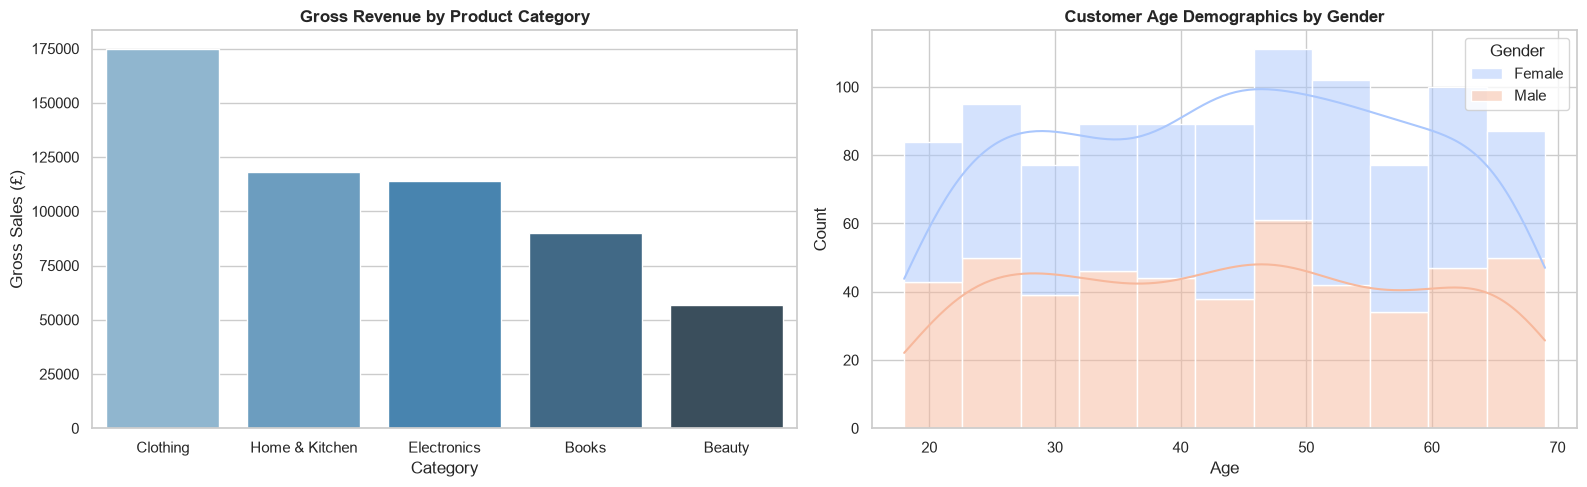

In [ ]:
## Step 4: Category Performance & Demographic Distribution
#Investigate sales distributions, volume by category, and gender purchasing behaviors.
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Total Revenue by Category (with modern hue & legend settings)
category_revenue = df.groupby('Category')['Total_Amount'].sum().sort_values(ascending=False).reset_index()
sns.barplot(
    data=category_revenue, 
    x='Category', 
    y='Total_Amount', 
    hue='Category', 
    legend=False, 
    ax=axes[0], 
    palette='Blues_d'
)
axes[0].set_title("Gross Revenue by Product Category", weight='bold')
axes[0].set_ylabel("Gross Sales (£)")

# Customer Age Distribution across Genders
sns.histplot(
    data=df, 
    x='Customer_Age', 
    hue='Gender', 
    multiple='stack', 
    kde=True, 
    ax=axes[1], 
    palette='coolwarm'
)
axes[1].set_title("Customer Age Demographics by Gender", weight='bold')
axes[1].set_xlabel("Age")

plt.tight_layout()
plt.show()

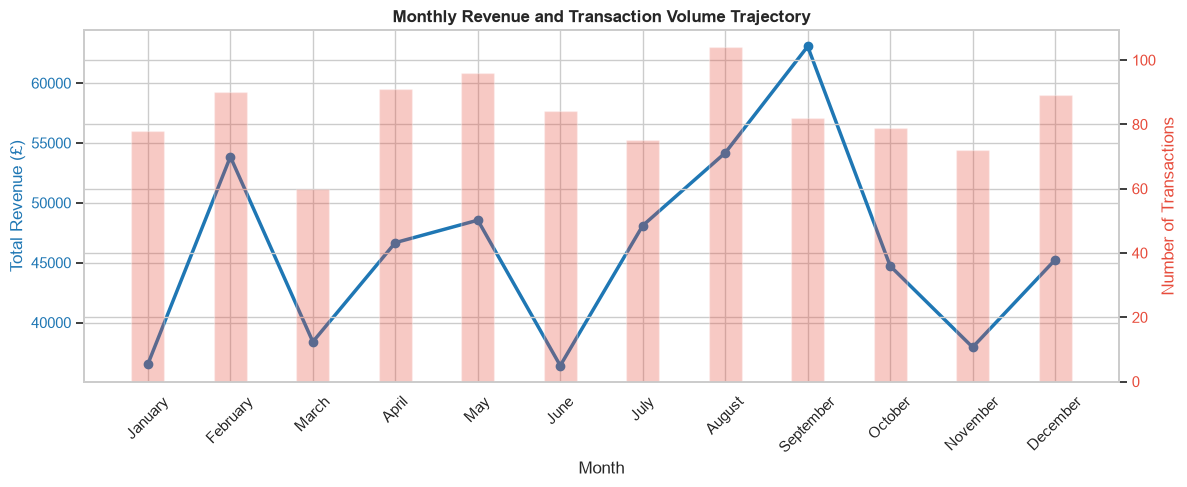

In [ ]:
## Step 5: Temporal Trends (Monthly Revenue Velocity)
#Track cumulative transactions and revenue behavior over time.
monthly_trends = df.groupby(['Month_Num', 'Month'])['Total_Amount'].agg(['sum', 'count']).reset_index()
monthly_trends = monthly_trends.sort_values('Month_Num')

fig, ax1 = plt.subplots(figsize=(12, 5))

color = '#1f77b4'
ax1.set_title("Monthly Revenue and Transaction Volume Trajectory", weight='bold')
ax1.set_xlabel("Month")
ax1.set_ylabel("Total Revenue (£)", color=color)
ax1.plot(monthly_trends['Month'], monthly_trends['sum'], color=color, marker='o', linewidth=2.5)
ax1.tick_params(axis='y', labelcolor=color)
plt.xticks(rotation=45)

ax2 = ax1.twinx()
color = '#e74c3c'
ax2.set_ylabel("Number of Transactions", color=color)
ax2.bar(monthly_trends['Month'], monthly_trends['count'], color=color, alpha=0.3, width=0.4)
ax2.tick_params(axis='y', labelcolor=color)

plt.tight_layout()
plt.show()

In [ ]:
## Step 6: Statistical Hypothesis Testing
#- **Null Hypothesis ($H_0$):** Mean transaction spend for Male customers equals mean transaction spend for Female customers ($\mu_1 = \mu_2$).
#- **Alternative Hypothesis ($H_1$):** Mean transaction spend differs significantly between genders ($\mu_1 \neq \mu_2$).
#- **Significance Level ($\alpha$):** 0.05
male_spend = df[df['Gender'] == 'Male']['Total_Amount']
female_spend = df[df['Gender'] == 'Female']['Total_Amount']

# Two-sample independent t-test
t_stat, p_value = stats.ttest_ind(male_spend, female_spend, equal_var=False)

print(f"Male Mean Spend:   £{male_spend.mean():.2f} (Std: {male_spend.std():.2f})")
print(f"Female Mean Spend: £{female_spend.mean():.2f} (Std: {female_spend.std():.2f})")
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value:     {p_value:.4f}")

if p_value < 0.05:
    print("\nOutcome: Reject H0 — Statistically significant difference in spend between genders.")
else:
    print("\nOutcome: Fail to Reject H0 — No statistically significant spend discrepancy by gender.")

Male Mean Spend:   £520.57 (Std: 545.15)
Female Mean Spend: £585.87 (Std: 804.07)
T-statistic: -1.5063
P-value:     0.1323

Outcome: Fail to Reject H0 — No statistically significant spend discrepancy by gender.


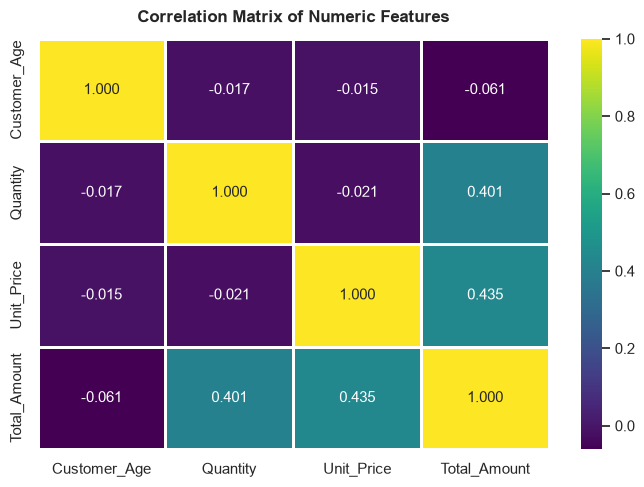

In [ ]:
## Step 7: Numerical Correlation & Metric Relationships
plt.figure(figsize=(7, 5))
num_df = df[['Customer_Age', 'Quantity', 'Unit_Price', 'Total_Amount']]
sns.heatmap(num_df.corr(), annot=True, cmap='viridis', fmt='.3f', linewidths=1)
plt.title("Correlation Matrix of Numeric Features", weight='bold', pad=12)
plt.tight_layout()
plt.show()